# Employee Performance Analysis

## Project Objective

The objective of this project is to analyze employee performance using various employee-related factors such as age, gender, department, salary, experience, work session, and location. This analysis helps identify patterns affecting employee performance and provides valuable insights for Human Resource (HR) decision-making.

The project includes:
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Visualization
- Statistical Analysis
- Machine Learning Model for Performance Prediction

## Import Required Libraries

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Machine Learning Libraries (used later)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

## Define Color Palette

In [6]:
primary = "#d59de3"
secondary = "#345882"
success = "#2ca02c"
danger = "#d62728"
warning = "#ff9896"

gradient = [
    "#d59de3",
    "#b291d6",
    "#8c83c9",
    "#5b6aa6",
    "#345882"
]

sns.set_style("whitegrid")

## Load Dataset

In [7]:
df = pd.read_csv("Employe_Performance_dataset.csv")

df.head()

,ID,Name,Age,Gender,Department,Salary,Joining Date,Performance Score,Experience,Status,Location,Session
0,1,Cory Escobar,48,Female,HR,5641,2015-05-03,2.0,16,Active,New York,Night
1,2,Timothy Sanchez,25,Other,Sales,4249,2020-11-09,2.0,11,Inactive,Los Angeles,Evening
2,3,Chad Nichols,57,Other,Sales,3058,2019-02-12,NaN,1,Inactive,New York,Morning
3,4,Christine Williams,58,Female,IT,5895,2017-09-08,2.0,13,Inactive,Los Angeles,Evening
4,5,Amber Harris,35,Other,IT,4317,2020-02-15,5.0,16,Inactive,New York,Evening


## Dataset Information

In [8]:
print("Shape of Dataset :", df.shape)

Shape of Dataset : (1000, 12)


In [9]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 1000
Columns : 12


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 1000 non-null   int64  
 1   Name               1000 non-null   object 
 2   Age                1000 non-null   int64  
 3   Gender             1000 non-null   object 
 4   Department         1000 non-null   object 
 5   Salary             1000 non-null   int64  
 6   Joining Date       1000 non-null   object 
 7   Performance Score  502 non-null    float64
 8   Experience         1000 non-null   int64  
 9   Status             1000 non-null   object 
 10  Location           1000 non-null   object 
 11  Session            1000 non-null   object 
dtypes: float64(1), int64(4), object(7)
memory usage: 93.9+ KB


In [10]:
df.columns

Index(['ID', 'Name', 'Age', 'Gender', 'Department', 'Salary', 'Joining Date',
       'Performance Score', 'Experience', 'Status', 'Location', 'Session'],
      dtype='object')

In [11]:
df.dtypes

,0
ID,int64
Name,object
Age,int64
Gender,object
Department,object
Salary,int64
Joining Date,object
Performance Score,float64
Experience,int64
Status,object


### Observation

The Employee Performance dataset contains employee-related information such as employee ID, age, gender, department, salary, joining date, experience, performance score, work status, office location, and work session.

The dataset consists of both numerical and categorical variables, making it suitable for exploratory data analysis, visualization, and machine learning.

## Data Quality Assessment

Before performing exploratory data analysis, it is important to evaluate the quality of the dataset. This section examines the dataset for missing values, duplicate records, unique values, descriptive statistics, and overall data consistency.

### Check Dataset Shape

In [12]:
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 1000
Number of Columns : 12


### Check Missing Values

In [13]:
missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": round((missing_values/len(df))*100,2)
})

missing_df

,Missing Values,Percentage (%)
ID,0,0.0
Name,0,0.0
Age,0,0.0
Gender,0,0.0
Department,0,0.0
Salary,0,0.0
Joining Date,0,0.0
Performance Score,498,49.8
Experience,0,0.0
Status,0,0.0


In [14]:
df["Performance Score"].fillna(
    df["Performance Score"].median(),
    inplace=True
)

In [15]:
df.isnull().sum()

,0
ID,0
Name,0
Age,0
Gender,0
Department,0
Salary,0
Joining Date,0
Performance Score,0
Experience,0
Status,0


### Observation

The dataset contains missing values only in the **Performance Score** column. Approximately **49.8%** of the records have missing performance scores.

Since this column is important for employee analysis and machine learning, removing these records would result in a significant loss of data. Therefore, the missing values were replaced using the **median**, which preserves the dataset while reducing the effect of outliers.

### Check Duplicate Records

In [16]:
duplicate_rows = df.duplicated().sum()

print("Total Duplicate Rows :", duplicate_rows)

Total Duplicate Rows : 0


In [17]:
if duplicate_rows > 0:
    df = df.drop_duplicates()
    print("Duplicate rows removed successfully.")
else:
    print("No duplicate rows found.")

No duplicate rows found.


### Observation

Duplicate records may affect statistical analysis and machine learning performance. Removing duplicate entries ensures data integrity.

### Check Unique Values

In [18]:
df.nunique().sort_values()

,0
Status,2
Gender,3
Location,3
Department,3
Session,3
Performance Score,5
Experience,20
Age,48
Joining Date,856
Salary,941


In [19]:
unique_df = pd.DataFrame({
    "Column":df.columns,
    "Unique Values":df.nunique().values
})

unique_df

,Column,Unique Values
0,ID,1000
1,Name,992
2,Age,48
3,Gender,3
4,Department,3
5,Salary,941
6,Joining Date,856
7,Performance Score,5
8,Experience,20
9,Status,2


### Statistical Summary

In [20]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,1000.0,500.500,288.819436,1.0,250.75,500.5,750.25,1000.0
Age,1000.0,40.782,14.124871,18.0,28.00,40.0,52.00,65.0
Salary,1000.0,5917.374,2299.418003,2015.0,3829.75,5889.0,7903.25,9993.0
Performance Score,1000.0,2.955,1.009948,1.0,3.00,3.0,3.00,5.0
Experience,1000.0,10.120,5.713689,1.0,5.00,10.0,15.00,20.0


### Statistical Summary for Categorical Features

In [21]:
df.describe(include='object').T

,count,unique,top,freq
Name,1000,992,Michael Lee,2
Gender,1000,3,Other,340
Department,1000,3,IT,339
Joining Date,1000,856,2021-10-30,4
Status,1000,2,Active,501
Location,1000,3,Los Angeles,335
Session,1000,3,Night,340


### Memory Usage

In [22]:
df.memory_usage(deep=True)

,0
Index,132
ID,8000
Name,62224
Age,8000
Gender,54004
Department,52014
Salary,8000
Joining Date,59000
Performance Score,8000
Experience,8000


### Data Quality Summary

The dataset has been inspected for data quality issues including missing values, duplicate records, unique values, descriptive statistics, and memory usage.

These checks ensure that the dataset is reliable and ready for exploratory data analysis and predictive modeling.

# Question 1

## Which department has the highest and lowest number of employees?

Understanding the distribution of employees across different departments helps identify workforce allocation within the organization. This analysis highlights departments with the largest and smallest employee counts.

In [23]:
department_count = df["Department"].value_counts()

department_count

,count
Department,
IT,339
Sales,338
HR,323


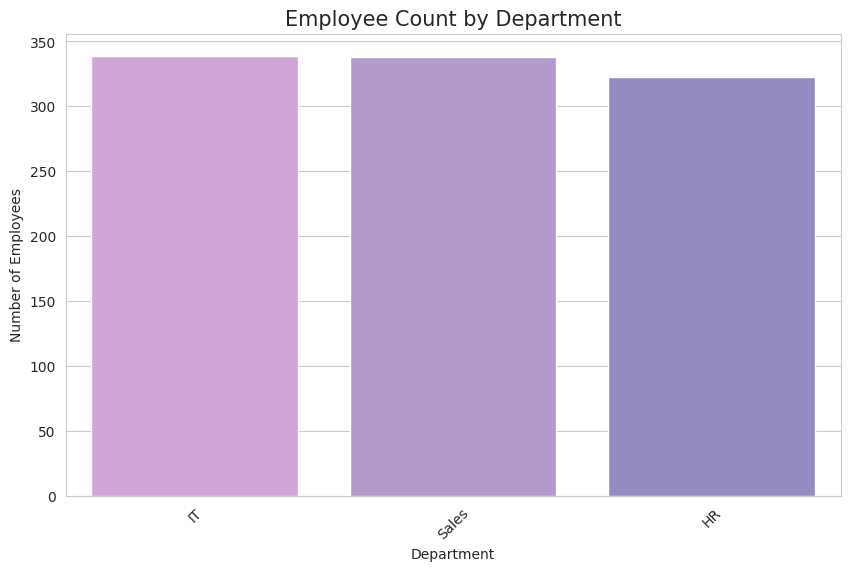

In [24]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=department_count.index,
    y=department_count.values,
    palette=gradient
)

plt.title("Employee Count by Department", fontsize=15)
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)

plt.show()

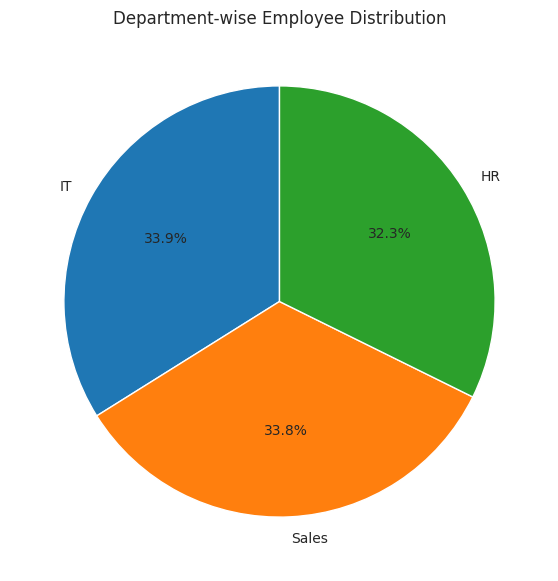

In [25]:
plt.figure(figsize=(7,7))

plt.pie(
    department_count,
    labels=department_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Department-wise Employee Distribution")

plt.show()

In [26]:
highest_department = department_count.idxmax()
highest_count = department_count.max()

lowest_department = department_count.idxmin()
lowest_count = department_count.min()

print("Highest Employee Department :", highest_department, "-", highest_count)

print("Lowest Employee Department :", lowest_department, "-", lowest_count)

Highest Employee Department : IT - 339
Lowest Employee Department : HR - 323


### Observation

- The bar chart shows the number of employees in each department.
- The pie chart represents the percentage distribution of employees across departments.
- The department with the highest employee count indicates where most of the workforce is concentrated.
- The department with the lowest employee count has comparatively fewer employees.

This analysis helps understand the organizational workforce distribution.

# Question 2

## What is the gender distribution of employees?

Gender distribution analysis provides insights into the workforce composition. It helps understand the proportion of male and female employees within the organization and supports diversity analysis.

In [27]:
gender_count = df["Gender"].value_counts()

gender_count

,count
Gender,
Other,340
Female,332
Male,328


In [28]:
gender_percentage = round((gender_count / len(df)) * 100, 2)

gender_percentage

,count
Gender,
Other,34.0
Female,33.2
Male,32.8


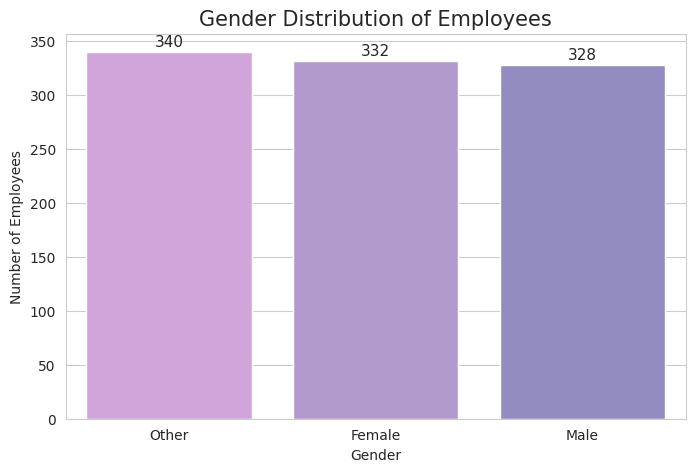

In [29]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=gender_count.index,
    y=gender_count.values,
    palette=gradient
)

plt.title("Gender Distribution of Employees", fontsize=15)
plt.xlabel("Gender")
plt.ylabel("Number of Employees")

for i, value in enumerate(gender_count.values):
    plt.text(i, value + 5, str(value), ha='center', fontsize=11)

plt.show()

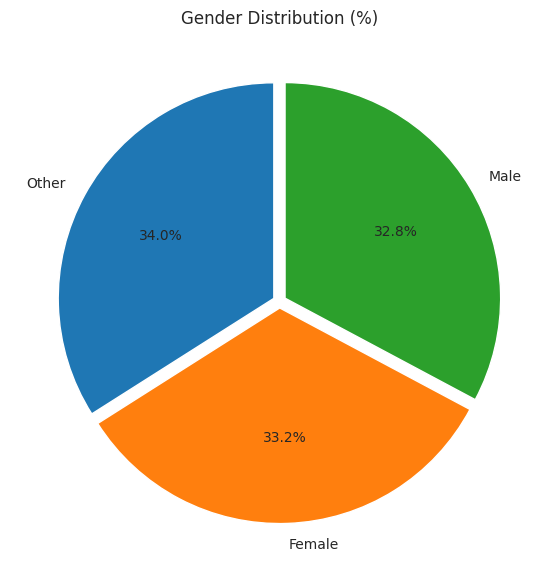

In [30]:
plt.figure(figsize=(7,7))

plt.pie(
    gender_count,
    labels=gender_count.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.03]*len(gender_count)
)

plt.title("Gender Distribution (%)")

plt.show()

In [31]:
highest_gender = gender_count.idxmax()
highest_count = gender_count.max()

lowest_gender = gender_count.idxmin()
lowest_count = gender_count.min()

print(f"Highest Employee Count : {highest_gender} ({highest_count})")
print(f"Lowest Employee Count  : {lowest_gender} ({lowest_count})")

Highest Employee Count : Other (340)
Lowest Employee Count  : Male (328)


In [32]:
gender_summary = pd.DataFrame({
    "Employee Count": gender_count,
    "Percentage (%)": gender_percentage
})

gender_summary

,Employee Count,Percentage (%)
Gender,,
Other,340,34.0
Female,332,33.2
Male,328,32.8


### Observation

- The dataset contains employees belonging to different genders.
- The bar chart displays the number of employees in each gender category.
- The pie chart illustrates the percentage share of each gender in the organization.
- The summary table presents both employee count and percentage for each gender.
- This analysis helps understand workforce diversity and employee representation.

# Question 3

## What is the age distribution of employees?

Employee age is an important demographic factor that helps understand the workforce composition. Analyzing age distribution provides insights into whether the organization has a younger, middle-aged, or experienced workforce.

In [33]:
df["Age"].describe()

,Age
count,1000.000000
mean,40.782000
std,14.124871
min,18.000000
25%,28.000000
50%,40.000000
75%,52.000000
max,65.000000


In [34]:
print("Minimum Age :", df["Age"].min())
print("Maximum Age :", df["Age"].max())
print("Average Age :", round(df["Age"].mean(),2))
print("Median Age  :", df["Age"].median())

Minimum Age : 18
Maximum Age : 65
Average Age : 40.78
Median Age  : 40.0


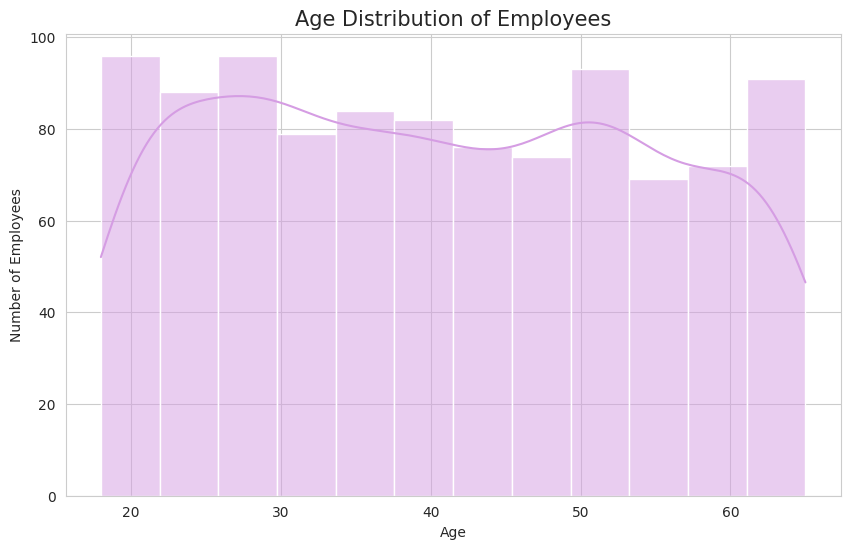

In [35]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Age",
    bins=12,
    kde=True,
    color=primary
)

plt.title("Age Distribution of Employees", fontsize=15)
plt.xlabel("Age")
plt.ylabel("Number of Employees")

plt.show()

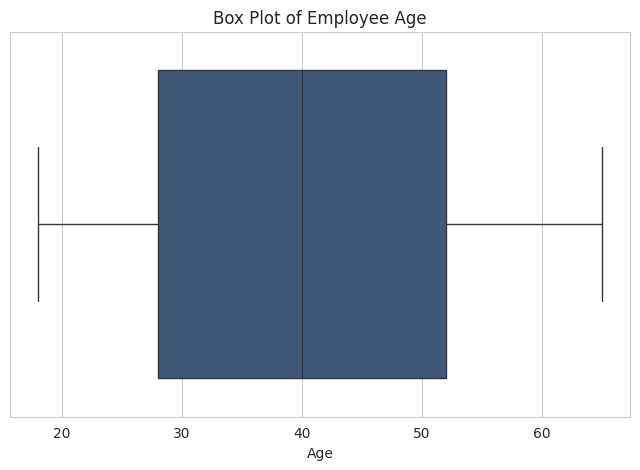

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Age"],
    color=secondary
)

plt.title("Box Plot of Employee Age")

plt.show()

In [37]:
age_groups = pd.cut(
    df["Age"],
    bins=[20,30,40,50,60],
    labels=["21-30","31-40","41-50","51-60"]
)

age_group_count = age_groups.value_counts().sort_index()

age_group_count

,count
Age,
21-30,221
31-40,204
41-50,197
51-60,194


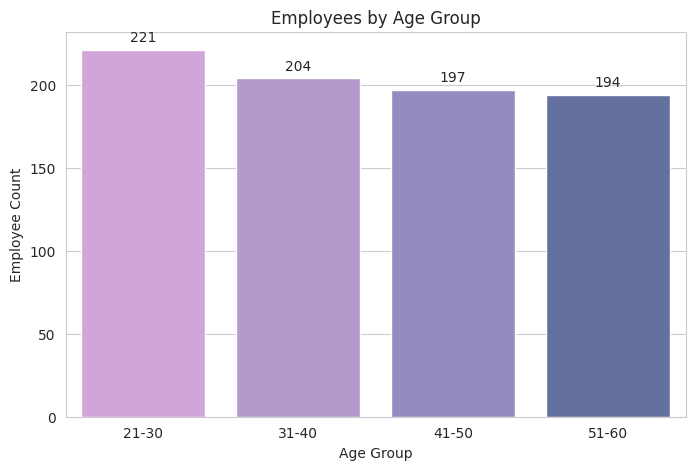

In [38]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=age_group_count.index,
    y=age_group_count.values,
    palette=gradient
)

plt.title("Employees by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Employee Count")

for i, value in enumerate(age_group_count.values):
    plt.text(i, value+5, str(value), ha='center')

plt.show()

In [39]:
age_summary = pd.DataFrame({
    "Age Group": age_group_count.index,
    "Employee Count": age_group_count.values,
    "Percentage (%)": np.round((age_group_count.values / len(df)) * 100, 2)
})

age_summary

,Age Group,Employee Count,Percentage (%)
0,21-30,221,22.1
1,31-40,204,20.4
2,41-50,197,19.7
3,51-60,194,19.4


### Observation

- The histogram shows how employee ages are distributed across the organization.
- The box plot helps identify the spread of ages and detect potential outliers.
- Employees are grouped into different age categories to better understand workforce demographics.
- The summary table presents the number and percentage of employees in each age group.
- This analysis helps HR understand the age composition of the workforce and supports workforce planning.

# Question 4

## How are employee salaries distributed across the organization?

Salary is one of the most important factors in employee analysis. This section explores the salary distribution, identifies the salary range, detects outliers, and groups employees into different salary categories.

In [40]:
df["Salary"].describe()

,Salary
count,1000.000000
mean,5917.374000
std,2299.418003
min,2015.000000
25%,3829.750000
50%,5889.000000
75%,7903.250000
max,9993.000000


In [41]:
print("Minimum Salary :", df["Salary"].min())
print("Maximum Salary :", df["Salary"].max())
print("Average Salary :", round(df["Salary"].mean(),2))
print("Median Salary  :", df["Salary"].median())

Minimum Salary : 2015
Maximum Salary : 9993
Average Salary : 5917.37
Median Salary  : 5889.0


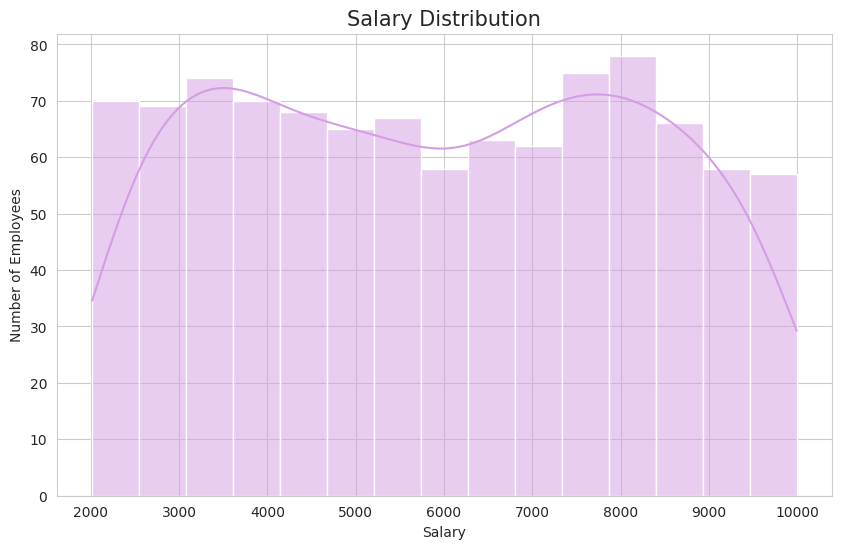

In [42]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Salary",
    bins=15,
    kde=True,
    color=primary
)

plt.title("Salary Distribution", fontsize=15)
plt.xlabel("Salary")
plt.ylabel("Number of Employees")

plt.show()

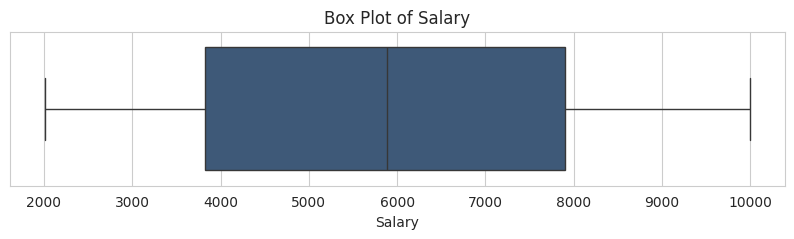

In [43]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["Salary"],
    color=secondary
)

plt.title("Box Plot of Salary")

plt.show()

In [44]:
salary_groups = pd.cut(
    df["Salary"],
    bins=5
)

salary_count = salary_groups.value_counts().sort_index()

salary_count

,count
Salary,
"(2007.022, 3610.6]",213
"(3610.6, 5206.2]",203
"(5206.2, 6801.8]",188
"(6801.8, 8397.4]",215
"(8397.4, 9993.0]",181


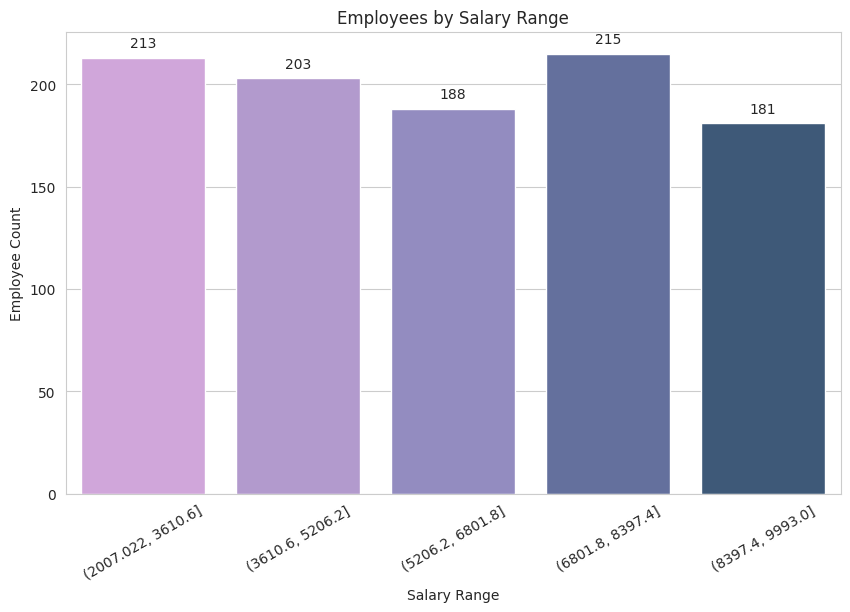

In [45]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=salary_count.index.astype(str),
    y=salary_count.values,
    palette=gradient
)

plt.title("Employees by Salary Range")
plt.xlabel("Salary Range")
plt.ylabel("Employee Count")

plt.xticks(rotation=30)

for i, value in enumerate(salary_count.values):
    plt.text(i, value+5, str(value), ha="center")

plt.show()

In [46]:
salary_summary = pd.DataFrame({
    "Salary Range": salary_count.index.astype(str),
    "Employee Count": salary_count.values,
    "Percentage (%)": np.round((salary_count.values/len(df))*100,2)
})

salary_summary

,Salary Range,Employee Count,Percentage (%)
0,"(2007.022, 3610.6]",213,21.3
1,"(3610.6, 5206.2]",203,20.3
2,"(5206.2, 6801.8]",188,18.8
3,"(6801.8, 8397.4]",215,21.5
4,"(8397.4, 9993.0]",181,18.1


In [47]:
highest_range = salary_summary.loc[
    salary_summary["Employee Count"].idxmax()
]

highest_range

,3
Salary Range,"(6801.8, 8397.4]"
Employee Count,215
Percentage (%),21.5


### Observation

- The histogram illustrates the overall salary distribution of employees.
- The box plot helps identify the spread of salaries and detect any potential outliers.
- Employees are grouped into different salary ranges to better understand salary distribution.
- The summary table displays the employee count and percentage in each salary range.
- The salary range with the highest employee count represents the most common salary bracket within the organization.

# Question 5

## How is employee experience distributed across the organization?

Employee experience plays an important role in determining productivity and performance. This analysis examines the distribution of experience, identifies common experience levels, and groups employees based on their years of experience.

In [48]:
df["Experience"].describe()

,Experience
count,1000.000000
mean,10.120000
std,5.713689
min,1.000000
25%,5.000000
50%,10.000000
75%,15.000000
max,20.000000


In [49]:
print("Minimum Experience :", df["Experience"].min(), "Years")
print("Maximum Experience :", df["Experience"].max(), "Years")
print("Average Experience :", round(df["Experience"].mean(),2), "Years")
print("Median Experience  :", df["Experience"].median(), "Years")

Minimum Experience : 1 Years
Maximum Experience : 20 Years
Average Experience : 10.12 Years
Median Experience  : 10.0 Years


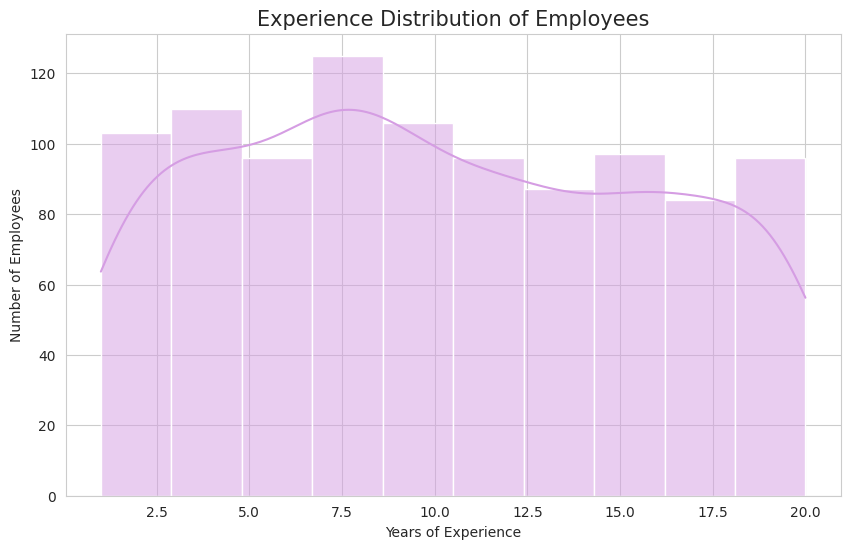

In [50]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Experience",
    bins=10,
    kde=True,
    color=primary
)

plt.title("Experience Distribution of Employees", fontsize=15)
plt.xlabel("Years of Experience")
plt.ylabel("Number of Employees")

plt.show()

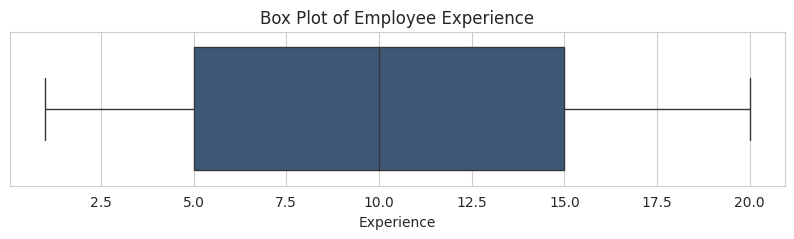

In [51]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["Experience"],
    color=secondary
)

plt.title("Box Plot of Employee Experience")

plt.show()

In [52]:
experience_groups = pd.cut(
    df["Experience"],
    bins=[0,2,5,10,15,20],
    labels=[
        "0-2 Years",
        "3-5 Years",
        "6-10 Years",
        "11-15 Years",
        "16-20 Years"
    ]
)

experience_count = experience_groups.value_counts().sort_index()

experience_count

,count
Experience,
0-2 Years,103
3-5 Years,154
6-10 Years,283
11-15 Years,231
16-20 Years,229


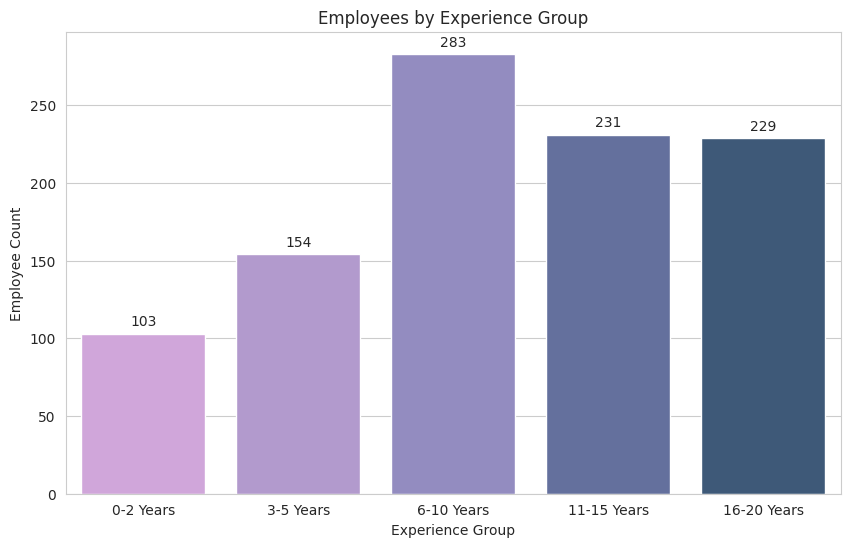

In [53]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=experience_count.index,
    y=experience_count.values,
    palette=gradient
)

plt.title("Employees by Experience Group")
plt.xlabel("Experience Group")
plt.ylabel("Employee Count")

for i, value in enumerate(experience_count.values):
    plt.text(i, value + 5, str(value), ha="center")

plt.show()

In [54]:
experience_summary = pd.DataFrame({
    "Experience Group": experience_count.index,
    "Employee Count": experience_count.values,
    "Percentage (%)": np.round((experience_count.values / len(df)) * 100, 2)
})

experience_summary

,Experience Group,Employee Count,Percentage (%)
0,0-2 Years,103,10.3
1,3-5 Years,154,15.4
2,6-10 Years,283,28.3
3,11-15 Years,231,23.1
4,16-20 Years,229,22.9


In [55]:
highest_group = experience_summary.loc[
    experience_summary["Employee Count"].idxmax()
]

highest_group

,2
Experience Group,6-10 Years
Employee Count,283
Percentage (%),28.3


### Observation

- The histogram shows the distribution of employee experience across the organization.
- The box plot highlights the spread of experience and identifies any outliers.
- Employees are categorized into different experience groups for better understanding.
- The summary table presents the employee count and percentage for each experience group.
- The experience group with the highest employee count represents the most common experience level in the organization.

# Question 6

## How are employee performance scores distributed?

Employee Performance Score is one of the most important indicators in this dataset. Analyzing its distribution helps understand overall employee performance, identify common performance levels, and detect any unusual patterns.

In [56]:
df["Performance Score"].describe()

,Performance Score
count,1000.000000
mean,2.955000
std,1.009948
min,1.000000
25%,3.000000
50%,3.000000
75%,3.000000
max,5.000000


In [57]:
print("Minimum Performance Score :", df["Performance Score"].min())
print("Maximum Performance Score :", df["Performance Score"].max())
print("Average Performance Score :", round(df["Performance Score"].mean(),2))
print("Median Performance Score  :", df["Performance Score"].median())

Minimum Performance Score : 1.0
Maximum Performance Score : 5.0
Average Performance Score : 2.96
Median Performance Score  : 3.0


In [58]:
performance_count = df["Performance Score"].value_counts().sort_index()

performance_count

,count
Performance Score,
1.0,103
2.0,125
3.0,585
4.0,88
5.0,99


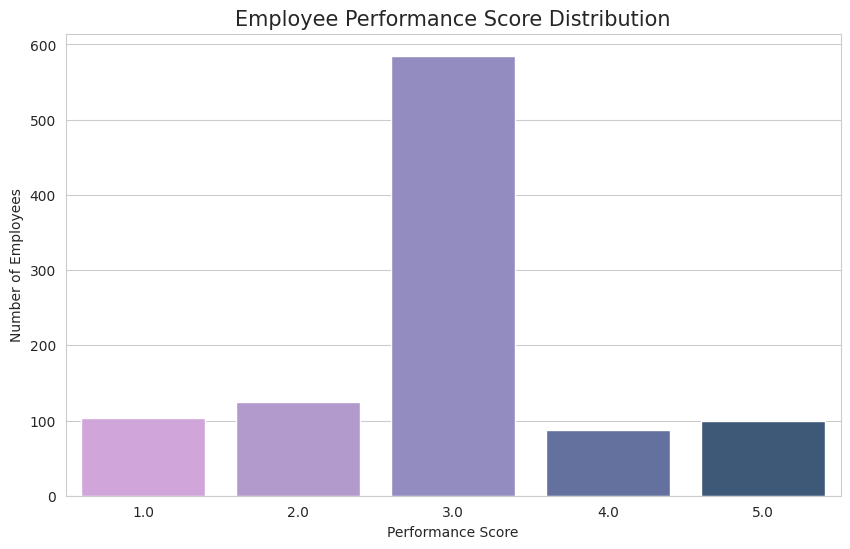

In [59]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="Performance Score",
    palette=gradient
)

plt.title("Employee Performance Score Distribution", fontsize=15)
plt.xlabel("Performance Score")
plt.ylabel("Number of Employees")

plt.show()

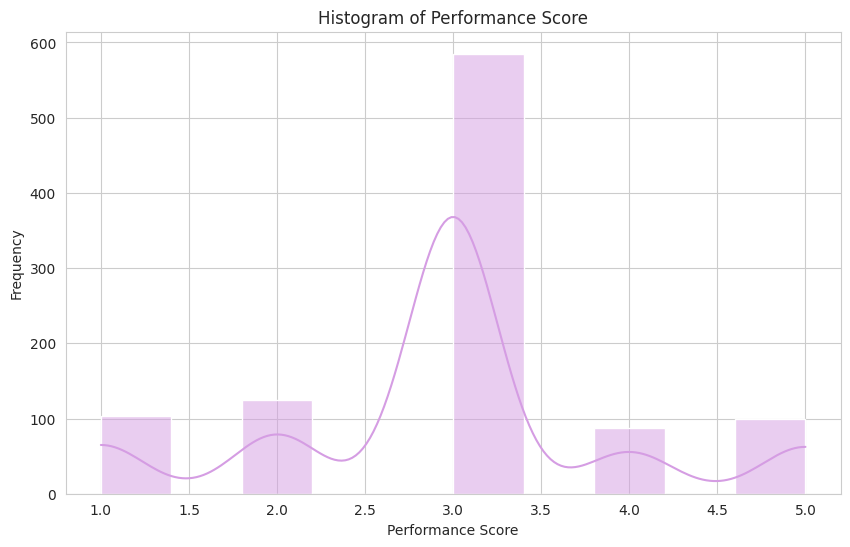

In [60]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Performance Score",
    bins=10,
    kde=True,
    color=primary
)

plt.title("Histogram of Performance Score")
plt.xlabel("Performance Score")
plt.ylabel("Frequency")

plt.show()

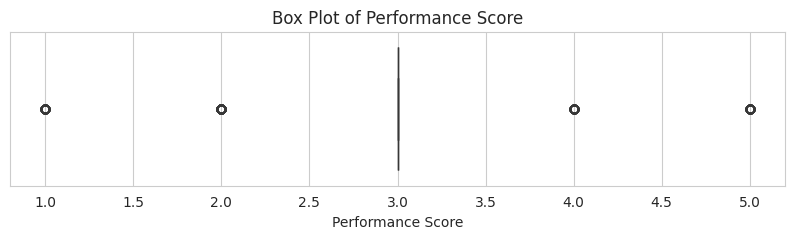

In [61]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["Performance Score"],
    color=secondary
)

plt.title("Box Plot of Performance Score")

plt.show()

In [62]:
performance_summary = pd.DataFrame({
    "Performance Score": performance_count.index,
    "Employee Count": performance_count.values,
    "Percentage (%)": np.round((performance_count.values / len(df)) * 100, 2)
})

performance_summary

,Performance Score,Employee Count,Percentage (%)
0,1.0,103,10.3
1,2.0,125,12.5
2,3.0,585,58.5
3,4.0,88,8.8
4,5.0,99,9.9


In [63]:
highest_score = performance_summary.loc[
    performance_summary["Employee Count"].idxmax()
]

highest_score

,2
Performance Score,3.0
Employee Count,585.0
Percentage (%),58.5


### Observation

- The descriptive statistics summarize the overall performance score distribution.
- The bar chart shows how many employees fall into each performance score category.
- The histogram illustrates the frequency distribution of performance scores.
- The box plot helps identify the spread of scores and any potential outliers.
- The summary table provides employee count and percentage for each performance score.
- The most common performance score represents the performance level achieved by the largest number of employees.

# Question 7

## How are employees distributed across different office locations?

Employee location analysis helps understand the geographical distribution of the workforce. It identifies locations with the highest and lowest number of employees and provides insights into organizational presence across different offices.

In [64]:
location_count = df["Location"].value_counts()

location_count

,count
Location,
Los Angeles,335
Chicago,333
New York,332


In [65]:
location_percentage = np.round(
    (location_count / len(df)) * 100,
    2
)

location_percentage

,count
Location,
Los Angeles,33.5
Chicago,33.3
New York,33.2


In [66]:
location_summary = pd.DataFrame({
    "Employee Count": location_count,
    "Percentage (%)": location_percentage
})

location_summary

,Employee Count,Percentage (%)
Location,,
Los Angeles,335,33.5
Chicago,333,33.3
New York,332,33.2


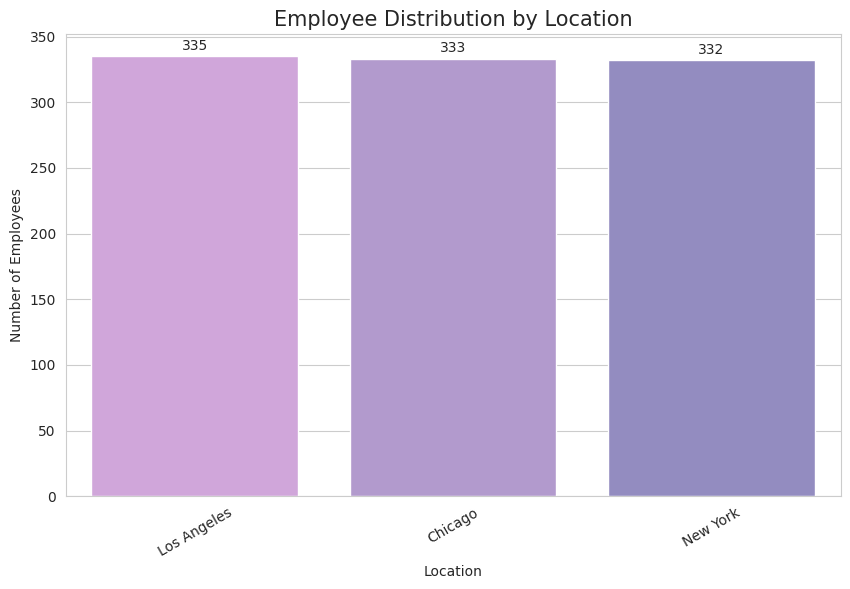

In [67]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=location_count.index,
    y=location_count.values,
    palette=gradient
)

plt.title("Employee Distribution by Location", fontsize=15)
plt.xlabel("Location")
plt.ylabel("Number of Employees")

plt.xticks(rotation=30)

for i, value in enumerate(location_count.values):
    plt.text(i, value+5, str(value), ha="center")

plt.show()

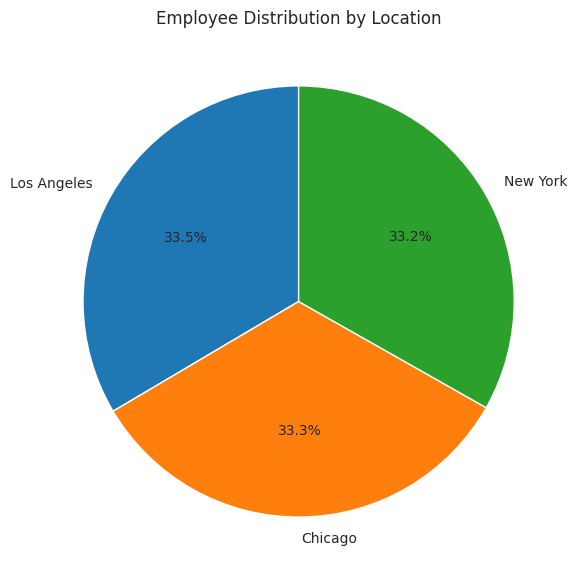

In [68]:
plt.figure(figsize=(7,7))

plt.pie(
    location_count,
    labels=location_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Employee Distribution by Location")

plt.show()

In [69]:
highest_location = location_count.idxmax()
highest_employee = location_count.max()

lowest_location = location_count.idxmin()
lowest_employee = location_count.min()

print("Location with Highest Employees :", highest_location)
print("Number of Employees :", highest_employee)

print()

print("Location with Lowest Employees :", lowest_location)
print("Number of Employees :", lowest_employee)

Location with Highest Employees : Los Angeles
Number of Employees : 335

Location with Lowest Employees : New York
Number of Employees : 332


In [70]:
location_summary.sort_values(
    by="Employee Count",
    ascending=False
)

,Employee Count,Percentage (%)
Location,,
Los Angeles,335,33.5
Chicago,333,33.3
New York,332,33.2


### Observation

- The dataset contains employees working across multiple office locations.
- The bar chart clearly compares the number of employees at each location.
- The pie chart shows the percentage distribution of employees by location.
- The summary table presents the employee count and percentage for every office location.
- The location with the highest employee count has the largest workforce, while the location with the lowest employee count has the smallest workforce.
- This analysis helps management understand workforce distribution across different office locations.

# Question 8

## How are employees distributed across different work sessions?

Work session analysis helps understand how employees are allocated across Morning, Evening, and Night shifts. This provides insights into workforce scheduling and operational planning.

In [71]:
session_count = df["Session"].value_counts()

session_count

,count
Session,
Night,340
Morning,334
Evening,326


In [72]:
session_percentage = round((session_count / len(df)) * 100, 2)

session_percentage

,count
Session,
Night,34.0
Morning,33.4
Evening,32.6


In [73]:
session_summary = pd.DataFrame({
    "Employee Count": session_count,
    "Percentage (%)": session_percentage
})

session_summary

,Employee Count,Percentage (%)
Session,,
Night,340,34.0
Morning,334,33.4
Evening,326,32.6


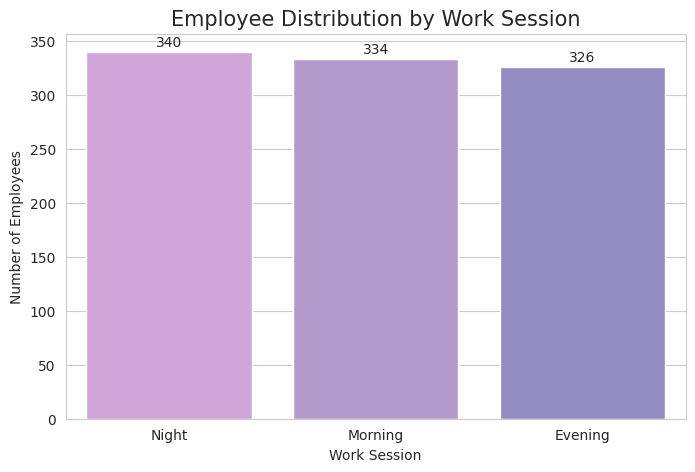

In [74]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=session_count.index,
    y=session_count.values,
    palette=gradient
)

plt.title("Employee Distribution by Work Session", fontsize=15)
plt.xlabel("Work Session")
plt.ylabel("Number of Employees")

for i, value in enumerate(session_count.values):
    plt.text(i, value + 5, str(value), ha='center')

plt.show()

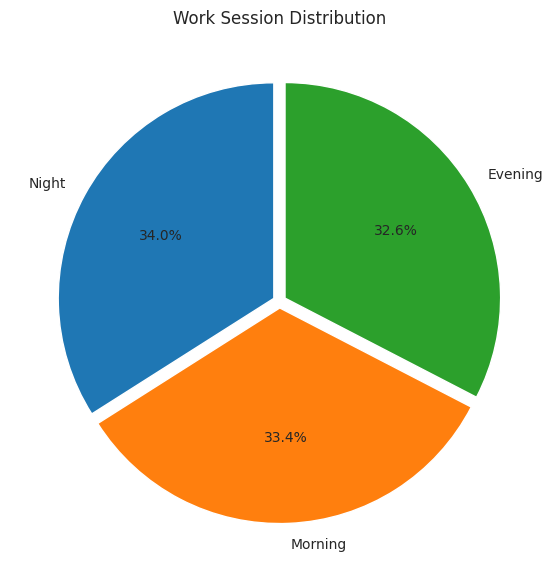

In [75]:
plt.figure(figsize=(7,7))

plt.pie(
    session_count,
    labels=session_count.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.03]*len(session_count)
)

plt.title("Work Session Distribution")

plt.show()

In [76]:
highest_session = session_count.idxmax()
highest_count = session_count.max()

lowest_session = session_count.idxmin()
lowest_count = session_count.min()

print(f"Highest Employee Session : {highest_session} ({highest_count})")
print(f"Lowest Employee Session  : {lowest_session} ({lowest_count})")

Highest Employee Session : Night (340)
Lowest Employee Session  : Evening (326)


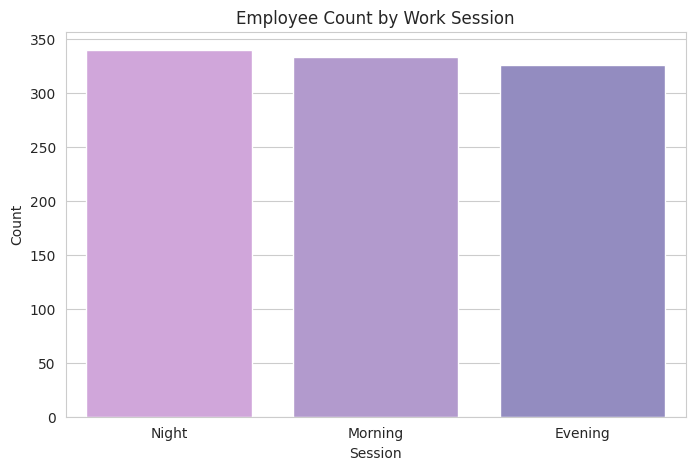

In [77]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Session",
    order=session_count.index,
    palette=gradient
)

plt.title("Employee Count by Work Session")
plt.xlabel("Session")
plt.ylabel("Count")

plt.show()

### Observation

- Employees are distributed across different work sessions such as Morning, Evening, and Night.
- The bar chart displays the number of employees assigned to each work session.
- The pie chart shows the percentage distribution of employees across sessions.
- The summary table provides both employee count and percentage for each session.
- Identifying the most and least common work sessions helps understand workforce allocation and scheduling patterns.

# Question 9

## What is the relationship between the numerical features in the dataset?

Correlation analysis helps identify the strength and direction of the relationship between numerical variables such as Age, Salary, Experience, and Performance Score. This analysis is useful for understanding which variables are positively or negatively associated.

In [78]:
numerical_columns = df.select_dtypes(include=["int64", "float64"])

numerical_columns.head()

,ID,Age,Salary,Performance Score,Experience
0,1,48,5641,2.0,16
1,2,25,4249,2.0,11
2,3,57,3058,3.0,1
3,4,58,5895,2.0,13
4,5,35,4317,5.0,16


In [79]:
correlation_matrix = numerical_columns.corr()

correlation_matrix

,ID,Age,Salary,Performance Score,Experience
ID,1.000000,0.038473,0.045047,0.000146,0.016102
Age,0.038473,1.000000,-0.032772,-0.044124,0.005645
Salary,0.045047,-0.032772,1.000000,0.001703,0.003882
Performance Score,0.000146,-0.044124,0.001703,1.000000,-0.007043
Experience,0.016102,0.005645,0.003882,-0.007043,1.000000


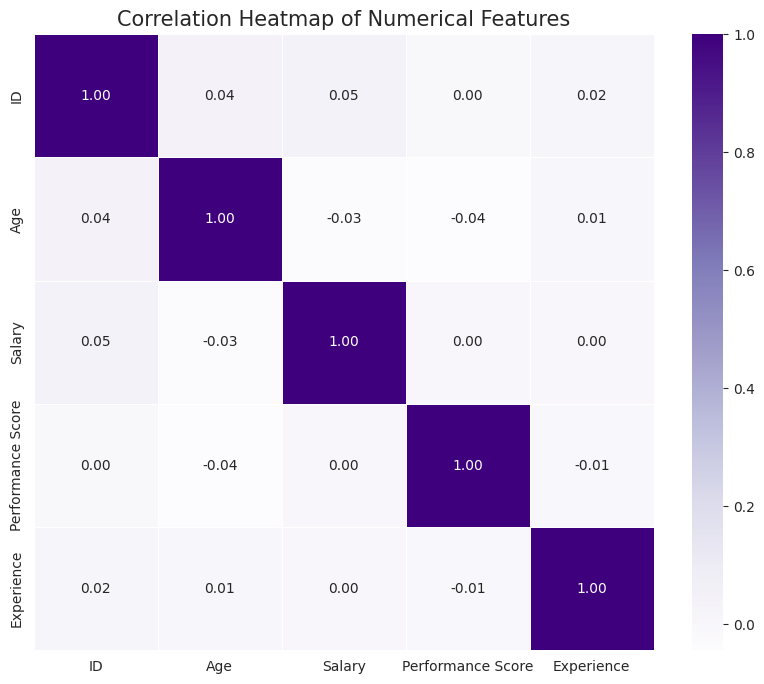

In [80]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Purples",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=15)

plt.show()

<Figure size 800x600 with 0 Axes>

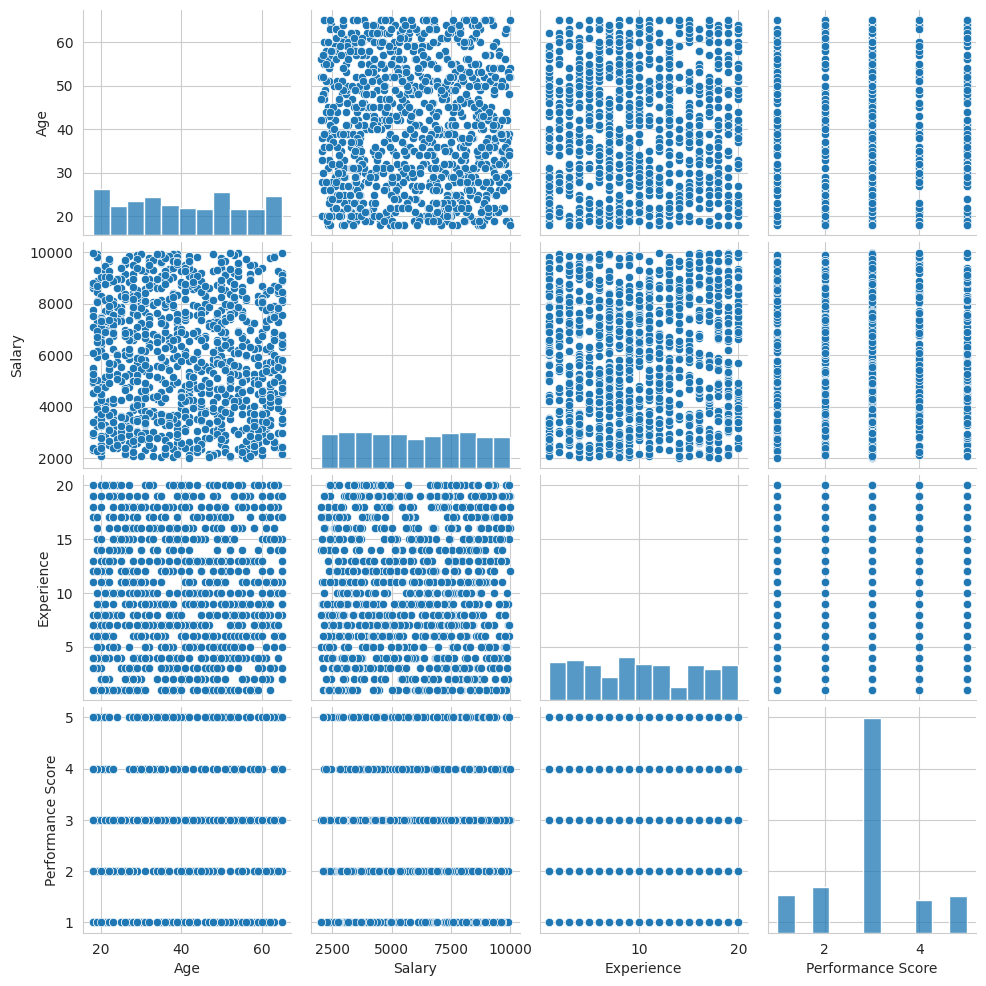

In [81]:
plt.figure(figsize=(8,6))

sns.pairplot(
    df[["Age", "Salary", "Experience", "Performance Score"]]
)

plt.show()

In [82]:
correlation_with_performance = correlation_matrix["Performance Score"].sort_values(ascending=False)

correlation_with_performance

,Performance Score
Performance Score,1.000000
Salary,0.001703
ID,0.000146
Experience,-0.007043
Age,-0.044124


In [83]:
print("Correlation with Performance Score:\n")
print(correlation_with_performance)

Correlation with Performance Score:

Performance Score    1.000000
Salary               0.001703
ID                   0.000146
Experience          -0.007043
Age                 -0.044124
Name: Performance Score, dtype: float64


### Observation

- The correlation matrix illustrates the relationship between all numerical features.
- Positive correlation values indicate that two variables tend to increase together.
- Negative correlation values indicate that as one variable increases, the other tends to decrease.
- Variables with correlation values close to **1** or **-1** have a stronger relationship, while values close to **0** indicate a weak relationship.
- Understanding these relationships helps in selecting useful features for machine learning models.

# Question 10

## Which employees have the highest performance scores?

This analysis identifies the top-performing employees based on their Performance Score. It helps recognize employees with exceptional performance and provides insights into their department, experience, and salary.

In [84]:
top_performers = df.sort_values(
    by="Performance Score",
    ascending=False
)

top_performers.head(10)

,ID,Name,Age,Gender,Department,Salary,Joining Date,Performance Score,Experience,Status,Location,Session
976,977,Kimberly Ross,19,Male,Sales,9331,2018-07-03,5.0,12,Active,New York,Morning
25,26,Tara Blackwell,30,Other,HR,6120,2020-02-20,5.0,7,Active,New York,Evening
751,752,David Powell IV,40,Other,IT,8831,2021-01-27,5.0,8,Active,New York,Morning
753,754,Kelly Sutton,28,Female,IT,9146,2022-10-16,5.0,13,Active,Chicago,Evening
732,733,Jay Evans,21,Male,HR,8147,2022-03-29,5.0,2,Inactive,Chicago,Morning
760,761,Taylor Dean,34,Female,Sales,4424,2021-08-22,5.0,19,Inactive,New York,Night
764,765,Roberta Haas,48,Male,HR,3927,2019-07-13,5.0,20,Inactive,Chicago,Evening
771,772,Willie Miller,39,Female,Sales,4949,2022-08-27,5.0,7,Inactive,New York,Evening
710,711,Ellen Barker,57,Female,IT,2096,2016-10-02,5.0,1,Inactive,New York,Night
718,719,Amy Miller,27,Other,HR,6899,2017-09-04,5.0,3,Inactive,New York,Morning


In [85]:
top10 = top_performers.head(10)[
    ["ID", "Name", "Department", "Experience", "Salary", "Performance Score"]
]

top10

,ID,Name,Department,Experience,Salary,Performance Score
976,977,Kimberly Ross,Sales,12,9331,5.0
25,26,Tara Blackwell,HR,7,6120,5.0
751,752,David Powell IV,IT,8,8831,5.0
753,754,Kelly Sutton,IT,13,9146,5.0
732,733,Jay Evans,HR,2,8147,5.0
760,761,Taylor Dean,Sales,19,4424,5.0
764,765,Roberta Haas,HR,20,3927,5.0
771,772,Willie Miller,Sales,7,4949,5.0
710,711,Ellen Barker,IT,1,2096,5.0
718,719,Amy Miller,HR,3,6899,5.0


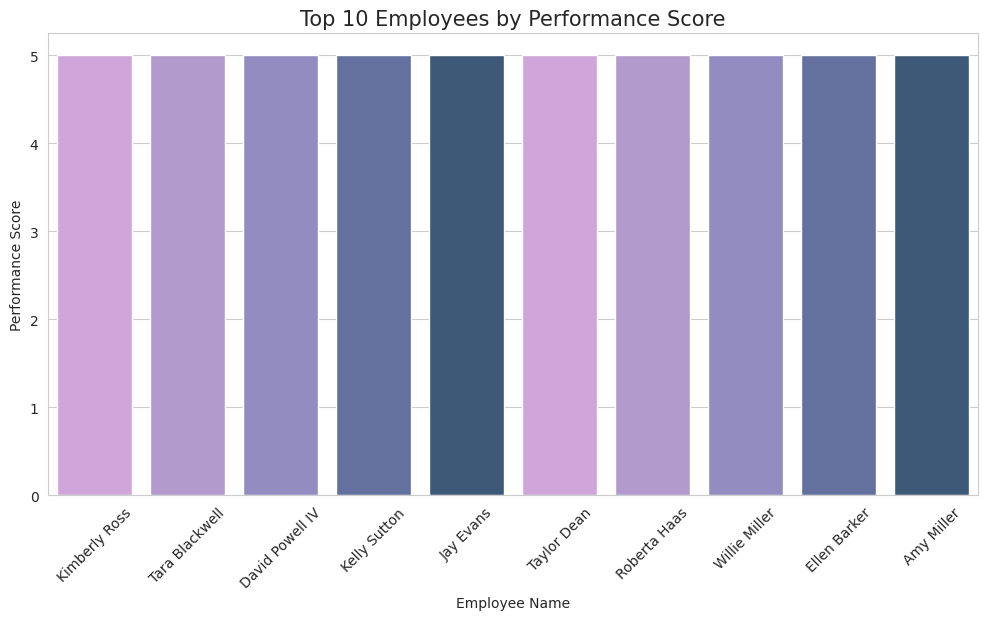

In [86]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="Name",
    y="Performance Score",
    palette=gradient
)

plt.title("Top 10 Employees by Performance Score", fontsize=15)
plt.xlabel("Employee Name")
plt.ylabel("Performance Score")

plt.xticks(rotation=45)

plt.show()

In [87]:
department_performance = (
    df.groupby("Department")["Performance Score"]
      .mean()
      .sort_values(ascending=False)
)

department_performance

,Performance Score
Department,
IT,2.988201
Sales,2.949704
HR,2.925697


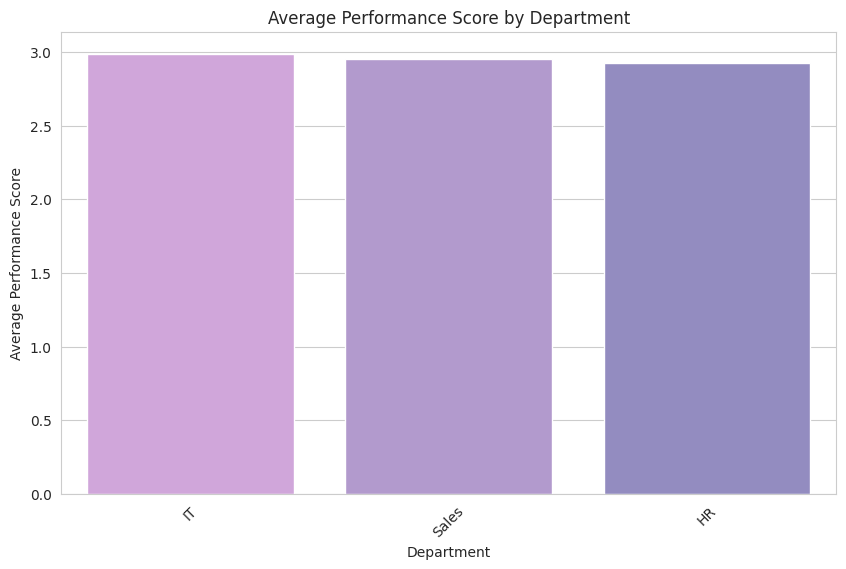

In [88]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=department_performance.index,
    y=department_performance.values,
    palette=gradient
)

plt.title("Average Performance Score by Department")
plt.xlabel("Department")
plt.ylabel("Average Performance Score")

plt.xticks(rotation=45)

plt.show()

In [89]:
highest_employee = df.loc[
    df["Performance Score"].idxmax()
]

highest_employee

,4
ID,5
Name,Amber Harris
Age,35
Gender,Other
Department,IT
Salary,4317
Joining Date,2020-02-15
Performance Score,5.0
Experience,16
Status,Inactive


In [90]:
print("Highest Performance Score :", df["Performance Score"].max())

print("Employee Name :", highest_employee["Name"])

print("Department :", highest_employee["Department"])

Highest Performance Score : 5.0
Employee Name : Amber Harris
Department : IT


### Observation

- The top-performing employees were identified based on their Performance Score.
- The bar chart compares the performance scores of the top 10 employees.
- Department-wise average performance helps determine which department performs best overall.
- The employee with the highest performance score has been identified along with their department.
- These insights can help management recognize high performers and understand departmental performance trends.

# Machine Learning

## Predicting Employee Performance Score using Random Forest Regressor

In this section, a Machine Learning model is developed to predict the **Performance Score** of employees based on various employee attributes such as age, gender, department, salary, experience, status, location, and work session.

The workflow includes:

- Data Preprocessing
- Feature Encoding
- Feature Selection
- Train-Test Split
- Model Training
- Model Evaluation
- Feature Importance
- Model Saving

### Step 1 : Create a Copy of Dataset

In [91]:
ml_df = df.copy()

ml_df.head()

,ID,Name,Age,Gender,Department,Salary,Joining Date,Performance Score,Experience,Status,Location,Session
0,1,Cory Escobar,48,Female,HR,5641,2015-05-03,2.0,16,Active,New York,Night
1,2,Timothy Sanchez,25,Other,Sales,4249,2020-11-09,2.0,11,Inactive,Los Angeles,Evening
2,3,Chad Nichols,57,Other,Sales,3058,2019-02-12,3.0,1,Inactive,New York,Morning
3,4,Christine Williams,58,Female,IT,5895,2017-09-08,2.0,13,Inactive,Los Angeles,Evening
4,5,Amber Harris,35,Other,IT,4317,2020-02-15,5.0,16,Inactive,New York,Evening


### Step 2 : Select Features

In [92]:
ml_df.columns

Index(['ID', 'Name', 'Age', 'Gender', 'Department', 'Salary', 'Joining Date',
       'Performance Score', 'Experience', 'Status', 'Location', 'Session'],
      dtype='object')

### Step 3 : Remove Unnecessary Columns

Employee ID, Name and Joining Date are not useful for predicting employee performance, so they are removed before model training.

In [93]:
ml_df = ml_df.drop(
    columns=[
        "ID",
        "Name",
        "Joining Date"
    ]
)

ml_df.head()

,Age,Gender,Department,Salary,Performance Score,Experience,Status,Location,Session
0,48,Female,HR,5641,2.0,16,Active,New York,Night
1,25,Other,Sales,4249,2.0,11,Inactive,Los Angeles,Evening
2,57,Other,Sales,3058,3.0,1,Inactive,New York,Morning
3,58,Female,IT,5895,2.0,13,Inactive,Los Angeles,Evening
4,35,Other,IT,4317,5.0,16,Inactive,New York,Evening


### Step 4 : Encode Categorical Variables

Machine Learning algorithms cannot understand text values directly. Therefore, categorical columns are converted into numerical values using Label Encoding.

In [94]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = ml_df.select_dtypes(include="object").columns

for column in categorical_columns:
    ml_df[column] = encoder.fit_transform(ml_df[column])

ml_df.head()

,Age,Gender,Department,Salary,Performance Score,Experience,Status,Location,Session
0,48,0,0,5641,2.0,16,0,2,2
1,25,2,2,4249,2.0,11,1,1,0
2,57,2,2,3058,3.0,1,1,2,1
3,58,0,1,5895,2.0,13,1,1,0
4,35,2,1,4317,5.0,16,1,2,0


### Step 5 : Verify Encoded Dataset

In [95]:
ml_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                1000 non-null   int64  
 1   Gender             1000 non-null   int64  
 2   Department         1000 non-null   int64  
 3   Salary             1000 non-null   int64  
 4   Performance Score  1000 non-null   float64
 5   Experience         1000 non-null   int64  
 6   Status             1000 non-null   int64  
 7   Location           1000 non-null   int64  
 8   Session            1000 non-null   int64  
dtypes: float64(1), int64(8)
memory usage: 70.4 KB


In [96]:
ml_df.head()

,Age,Gender,Department,Salary,Performance Score,Experience,Status,Location,Session
0,48,0,0,5641,2.0,16,0,2,2
1,25,2,2,4249,2.0,11,1,1,0
2,57,2,2,3058,3.0,1,1,2,1
3,58,0,1,5895,2.0,13,1,1,0
4,35,2,1,4317,5.0,16,1,2,0


### Observation

All categorical variables have been successfully converted into numerical values using Label Encoding. The dataset is now ready for feature selection and model training.

### Step 6 : Feature Selection

Separate the independent variables (features) and the dependent variable (target).

In [97]:
X = ml_df.drop("Performance Score", axis=1)

y = ml_df["Performance Score"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (1000, 8)
Target Shape : (1000,)


### Step 7 : Split the Dataset

The dataset is divided into training and testing sets. The training data is used to train the model, while the testing data is used to evaluate its performance.

In [98]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (800, 8)
Testing Data : (200, 8)


### Step 8 : Train the Random Forest Regression Model

In [99]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully.")

Model Trained Successfully.


### Step 9 : Predict Employee Performance Score

In [100]:
y_pred = model.predict(X_test)

y_pred[:10]

array([2.67, 2.62, 3.11, 2.42, 3.02, 3.57, 2.55, 2.83, 3.23, 2.37])

### Step 10 : Model Evaluation

In [101]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", round(mae,2))
print("Mean Squared Error :", round(mse,2))
print("Root Mean Squared Error :", round(rmse,2))
print("R² Score :", round(r2,2))

Mean Absolute Error : 0.81
Mean Squared Error : 1.18
Root Mean Squared Error : 1.09
R² Score : -0.13


### Observation

The Random Forest Regression model was trained using employee-related features. The evaluation metrics (MAE, RMSE, and R² Score) indicate how well the model predicts employee performance scores on the test dataset.

### Step 11 : Feature Importance

Feature Importance helps identify which employee attributes contribute the most to predicting employee performance.

In [102]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
3,Salary,0.331737
0,Age,0.222222
4,Experience,0.180339
7,Session,0.061270
6,Location,0.058581
2,Department,0.057960
1,Gender,0.054171
5,Status,0.033721


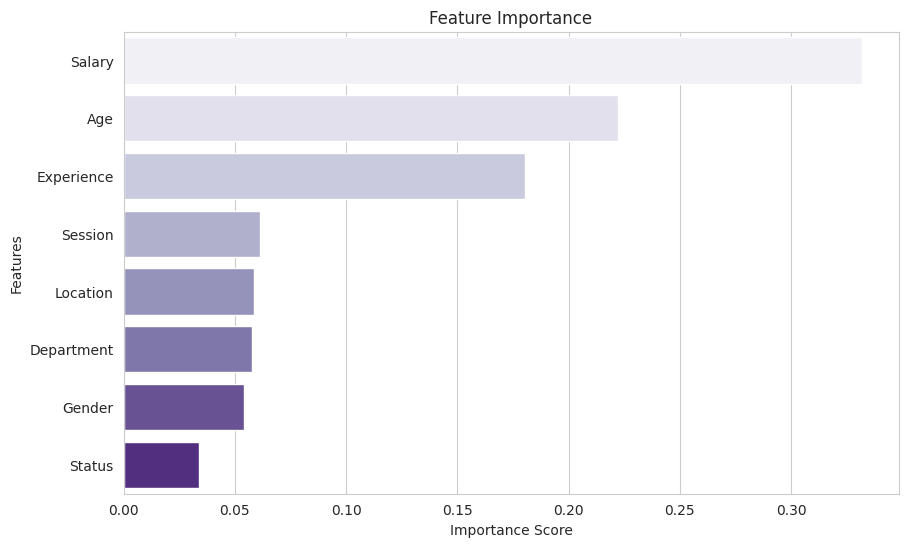

In [103]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    palette="Purples"
)

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

### Observation

The Feature Importance graph shows which employee attributes have the greatest influence on predicting the Performance Score.

Features with higher importance contribute more to the model's predictions than features with lower importance.

### Step 12 : Actual vs Predicted Performance Score

In [104]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,3.0,2.67
1,2.0,2.62
2,3.0,3.11
3,3.0,2.42
4,5.0,3.02
5,3.0,3.57
6,3.0,2.55
7,4.0,2.83
8,3.0,3.23
9,3.0,2.37


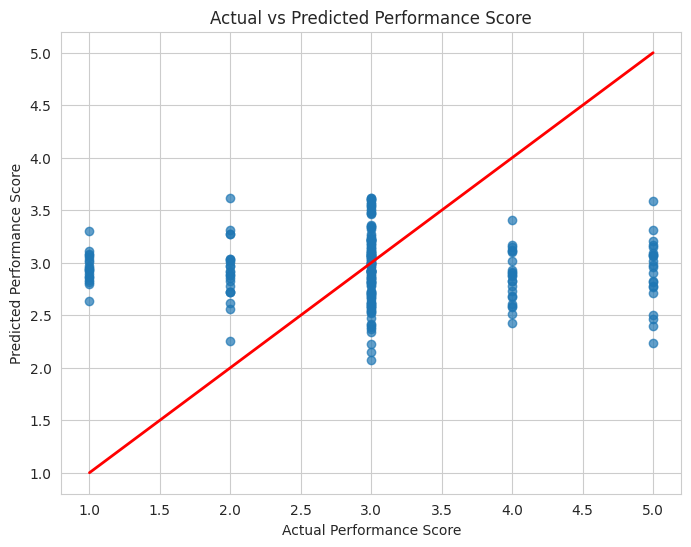

In [105]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Performance Score")
plt.ylabel("Predicted Performance Score")
plt.title("Actual vs Predicted Performance Score")

plt.show()

### Observation

The scatter plot compares the actual performance scores with the predicted scores.

The prediction points are close to the red reference line, the model is performing well.

### Step 13 : Residual Distribution

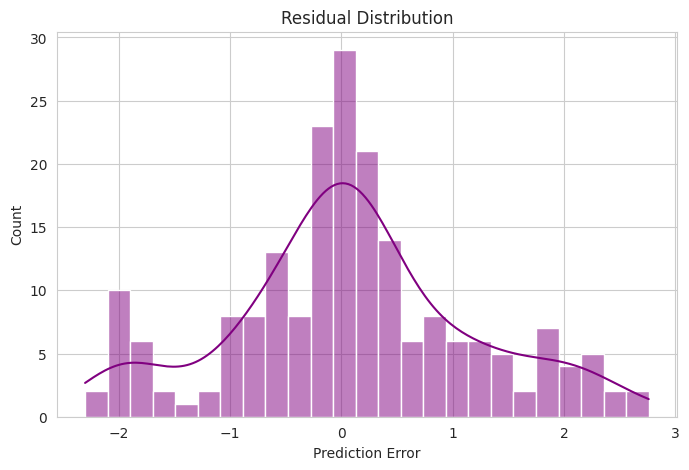

In [106]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=25,
    kde=True,
    color="purple"
)

plt.title("Residual Distribution")
plt.xlabel("Prediction Error")

plt.show()

### Observation

Residuals represent the difference between actual and predicted performance scores.

A distribution centered around zero indicates that the model predictions are reasonably accurate.

### Step 14 : Save the Trained Model

In [107]:
import joblib

joblib.dump(model, "employee_performance_model.pkl")

print("Model saved successfully.")

Model saved successfully.


## Machine Learning Summary

The Random Forest Regression model was successfully trained to predict employee performance using employee-related features.

The model was evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

Feature Importance analysis helped identify the most influential factors affecting employee performance. The trained model was also saved for future use.